# GRAPH CONVOLUTIONAL NEURAL NETWORK

## PARAMETER CONFIGURATION

In [2]:
batch_size = 8
#  splitting the dataset manually
train_files = [
    # FP11
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_3/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_4/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_5/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_6/TRAJ-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_7/TRAJ-76-150ns.nc"},
    # FP12
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_3/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_4/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_5/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_6/TRAJ-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_7/TRAJ-76-150ns.nc"}
]

test_files = [
    # FP11
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_3/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_4/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_5/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_6/TRAJ-76-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_7/TRAJ-150ns.nc"},
    # FP12
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_3/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_4/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_5/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_6/TRAJ-76-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_7/TRAJ-150ns.nc"}
]
#####

selection_string = "resid 613:754" #Full-atom MD2
epochs = 10
lr = 0.0001
test_size = 0.20
random_state = 42

In [4]:
train_files

[{'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_3/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_4/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_5/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_6/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_3/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_4/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_5/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_fi

In [5]:
test_files

[{'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_7/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_7/TRAJ-150ns.nc'}]

In [6]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, AttentionalAggregation
from torch_geometric.nn import radius_graph
from torch_geometric.utils import scatter
from sklearn.model_selection import train_test_split

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

/usr/local/jupyter-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
torch.cuda.is_available()

True

## DATA LOAD

In [8]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [9]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

### Manual Data Splitting

In [10]:
train_trj = []

for file in train_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    train_trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
train_trj[:5]

../FP11/PRODUCTION_3/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_4/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_5/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_6/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_3/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_4/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_5/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_6/TRAJ-150ns.nc
15000


[Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1])]

In [11]:
len(train_trj)

120000

In [12]:
test_trj = []

for file in test_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    test_trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
test_trj[:5]

../FP11/PRODUCTION_7/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_7/TRAJ-150ns.nc
15000


[Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1]),
 Data(pos=[2289, 3], res=[2289], types=[2289], label=[1])]

In [13]:
len(test_trj)

30000

In [10]:
# First 750 frames for training and last 750 frames for test
frames_per_simulation = 7500
chunk_size = 3750

train_trj = []
test_trj = []

# 
for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    train_trj.extend(simulation_frames[:chunk_size]) # First 750 frames to train
    test_trj.extend(simulation_frames[chunk_size:]) # Last 750 frames to test

In [11]:
len(train_trj)

37500

In [12]:
len(test_trj)

37500

In [11]:
# Split every 100 frames
frames_per_simulation = 7500
chunk_size = 100

train_trj = []
test_trj = []

for i in range(0, len(trj), frames_per_simulation):
    simulation_frames = trj[i:i + frames_per_simulation] # Extract the current simulation frames
    for j in range(0, frames_per_simulation, chunk_size): 
        chunk = simulation_frames[j:j + chunk_size] # Iterate each 100 frames
        if(j // chunk_size) % 2 == 0: # If index of chunk is even (0, 2, 4, etc) go to train
            train_trj.extend(chunk)
        else:
            test_trj.extend(chunk) # If odd (1, 3, 5, etc) go to test

In [12]:
len(train_trj)

38000

In [13]:
len(test_trj)

37000

## GRAPH MANIPULATION

In [22]:
import networkx as nx
train_trj[20]
edges = radius_graph(train_trj[20].pos, r=1.5)
G = nx.Graph()
G.add_edges_from(edges.T.tolist())

In [23]:
len(list(nx.connected_components(G)))

130

## MODEL

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius
        self.embed_res = Embedding(num_embeddings=24, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        # RESDIUE TYPE BRANCH
        self.conv1_res = GCNConv(128, 64)
        self.relu1_res = ReLU()
        self.conv2_res = GCNConv(64, 32)
        self.relu2_res = ReLU()
        self.conv3_res = GCNConv(32, 16)
        # ATOM TYPE BRANCH
        self.conv1_type = GCNConv(128, 64)
        self.relu1_type = ReLU()
        self.conv2_type = GCNConv(64, 32)
        self.relu2_type = ReLU()
        self.conv3_type = GCNConv(32, 16)
        # ATTENTION MECHANISM IN POOLING LAYER
        self.pool_res = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        self.pool_type = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        # LINEAR LAYER
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        # FORWARD PASS OF RESIDUES TYPES
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        # FORWARD PASS OF ATOMS TYPES
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        #z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        #z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        # FORWARD PASS POOLING AND LINEAR LAYER
        z_res = self.pool_res(z_res, data.batch)
        z_type = self.pool_type(z_type, data.batch)
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        #z = F.softmax(z, dim=1) #CrossEntropyLoss already does softmax at the end
        return z

In [43]:
#train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [44]:
#!pip install networkx
#import networkx as nx
#train_trj[0]
#edges = radius_graph(train_trj[0].pos, r=5.0)
#G = nx.Graph()
#G.add_edges_from(edges.T.tolist())
#len(list(nx.connected_components(G)))
#nx.write_graphml(G, "foo.graphml")
#!nvidia-smi

## VALIDATION

In [18]:
gcn = GCN(radius=4.0).to(torch.device("cuda:0"))
loss = CrossEntropyLoss()
optimizer = torch.optim.Adam(gcn.parameters(), lr=lr, weight_decay=5e-4)
train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
history = []
for i in tqdm.tqdm(range(epochs)):
    statistics = dict()
    statistics['training_loss'] = 0.0
    gcn.train()
    for d in train_loader:
        d = d.to(torch.device("cuda:0"))
        optimizer.zero_grad()
        z = gcn(d)
        l = loss(z, d.label)
        l.backward()
        optimizer.step()
    statistics['training_loss'] += l.item()
    gcn.eval()
    with torch.no_grad():
        statistics['test_accuracy'] = 0.0
        statistics['test_loss'] = 0.0
        for d in test_loader:
            d = d.to(torch.device("cuda:0"))
            z = gcn(d)
            l = loss(z, d.label)
            a = ((z.argmax(1) == d.label).sum())
            statistics['test_accuracy'] += a.item()
            statistics['test_loss'] += l.item()
                
    statistics['test_accuracy'] /= len(test_trj)
    statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)

    print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
    history.append(statistics)

 10%|████████████████▋                                                                                                                                                      | 1/10 [06:09<55:28, 369.79s/it]

Epoch  1 | Accuracy 0.4999


 20%|█████████████████████████████████▍                                                                                                                                     | 2/10 [12:20<49:20, 370.11s/it]

Epoch  2 | Accuracy 0.4994


 30%|██████████████████████████████████████████████████                                                                                                                     | 3/10 [18:33<43:20, 371.50s/it]

...

Epoch  8 | Accuracy 0.7565


 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                | 9/10 [55:28<06:10, 370.42s/it]

Epoch  9 | Accuracy 0.7539


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:02:05<00:00, 372.58s/it]

Epoch 10 | Accuracy 0.7280


In [19]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.686213,0.499867,0.691925
1,0.616565,0.499400,0.663632
2,0.349129,0.596533,0.623347
3,0.278742,0.748533,0.507743
4,0.167025,0.760567,0.500706
5,0.231124,0.746900,0.536514
6,0.242724,0.767300,0.508732
7,0.043510,0.756500,0.545389
8,0.449373,0.753933,0.572803
9,0.123404,0.728033,0.661328


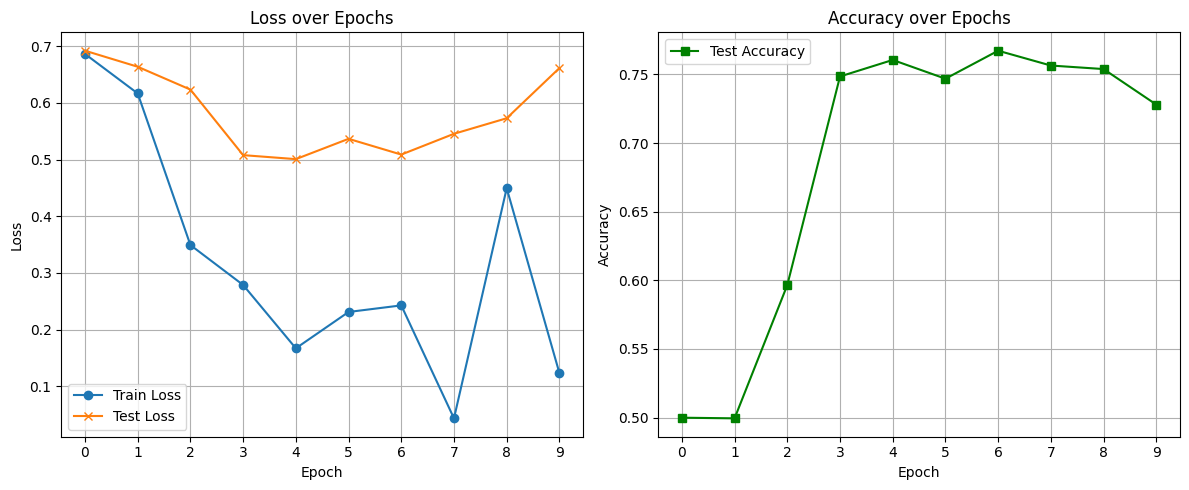

In [20]:
# Plotting the results
train_loss = [h['training_loss'] for h in history]
test_loss = [h['test_loss'] for h in history]
test_accuracy = [h['test_accuracy'] for h in history]
epochs_count = list(range(0, len(history)))
#epochs_count = list(range(0,20))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(test_loss, label='Test Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(test_accuracy, label='Test Accuracy', marker='s', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()